In [40]:
%run "Ch00 - Basic Imports and Set ups.ipynb"

### Bayes Theorem

In [41]:
import random

In [42]:
p_fake = 0.02
p_real = 0.98
p_detectfake_givenfake = 0.95
p_detectfake_givenreal = 0.10
result = (p_detectfake_givenfake * p_fake)/(p_detectfake_givenfake * p_fake + p_detectfake_givenreal * p_real)

In [43]:
result

0.16239316239316237

<hr class="red-dot-line">

Problem Statement
Suppose an email filtering system works like this:
30% of emails are spam
70% of emails are normal
The spam filter detects spam using certain keywords.
Detection performance:
If an email is spam, the system detects it as spam 90% of the time
If an email is normal, it wrongly marks it as spam 20% of the time
Now suppose the system flags an email as spam.
Question
What is the probability that the email is actually spam?

In [52]:
p_spam = .3
p_real = 0.7
p_detectspam_givenspam = 0.9
p_detectreal_givenspam=0.1
p_detectspam_givenreal = .2
(p_detectspam_givenspam * p_spam)/(p_detectspam_givenspam * p_spam + p_detectspam_givenreal * p_real)


0.6585365853658537

In [55]:
(p_detectspam_givenreal * p_real)/(p_detectspam_givenreal * p_real  + p_detectspam_givenspam * p_spam)

0.34146341463414626

<hr class="red-dot-line">

### Dice

In [57]:
import pandas as pd
dice=[1,2,3,4,5,6]
prabability= [1/6]*6
df=pd.DataFrame({'Outcome':dice,'prabability':prabability})
df

,Outcome,prabability
0,1,0.166667
1,2,0.166667
2,3,0.166667
3,4,0.166667
4,5,0.166667
5,6,0.166667


----

### Hotel Data

In [59]:
import pandas as pd

# File path (update if needed)
file_path = "data/final_hotel.xlsx"

# Load Excel into pandas DataFrame
hotel_info = pd.read_excel(file_path)

# Preview data
print(hotel_info.head())



                             hotel name  rating rating text           place  \
0  The Fern Sattva Resort - Polo Forest     4.3   Excellent         Abhapur   
1                   Pride Resort Ambaji     3.8   Very Good          Ambaji   
2                       Royal Inn Hotel     3.9   Very Good      Danta Road   
3                 hotel leela residency     3.9   Very Good  Khodiyar Chowk   
4                     HOTEL KARDHAR INN     4.2   Very Good  Khodiyar Chowk   

                     near by place  discount price  actual price  \
0  96.8 km from Ambaji city centre            3896          6449   
1                    Not Available            2171          2875   
2                    Not Available            1356          2600   
3                    Not Available            1282          1500   
4                    Not Available            1563          3000   

         facilities destination name  
0               Spa           Ambaji  
1     Swimming Pool           Ambaji  

In [60]:
# Check structure
print(hotel_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2365 entries, 0 to 2364
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hotel name        2365 non-null   object 
 1   rating            2365 non-null   float64
 2   rating text       2365 non-null   object 
 3   place             2365 non-null   object 
 4   near by place     2365 non-null   object 
 5   discount price    2365 non-null   int64  
 6   actual price      2365 non-null   int64  
 7   facilities        2365 non-null   object 
 8   destination name  2365 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 166.4+ KB
None


In [72]:
hotel_info.columns = (
    hotel_info.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
)

In [74]:
print(hotel_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2365 entries, 0 to 2364
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hotel_name        2365 non-null   object 
 1   rating            2365 non-null   float64
 2   rating_text       2365 non-null   object 
 3   place             2365 non-null   object 
 4   near_by_place     2365 non-null   object 
 5   discount_price    2365 non-null   int64  
 6   actual_price      2365 non-null   int64  
 7   facilities        2365 non-null   object 
 8   destination_name  2365 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 166.4+ KB
None


### Q1 : average of Rating


In [73]:
print(hotel_info.rating.mean())

3.5407610993657506


### Q2 : How mnay hotels has rating more than 4

In [81]:
count_hotels = (hotel_info['rating'] > 4).sum()

In [76]:
print(count_hotels )

442


### Q3 :  Calcualte discount% for each hotel

In [77]:
hotel_info['discount_pct'] = (
    (hotel_info['actual_price'] - hotel_info['discount_price'])
    / hotel_info['actual_price']
) * 100

In [78]:
hotel_info.head()

,hotel_name,rating,rating_text,place,near_by_place,discount_price,actual_price,facilities,destination_name,discount_pct
0,The Fern Sattva Resort - Polo Forest,4.3,Excellent,Abhapur,96.8 km from Ambaji city centre,3896,6449,Spa,Ambaji,39.587533
1,Pride Resort Ambaji,3.8,Very Good,Ambaji,Not Available,2171,2875,Swimming Pool,Ambaji,24.486957
2,Royal Inn Hotel,3.9,Very Good,Danta Road,Not Available,1356,2600,Restaurant,Ambaji,47.846154
3,hotel leela residency,3.9,Very Good,Khodiyar Chowk,Not Available,1282,1500,Air Conditioning,Ambaji,14.533333
4,HOTEL KARDHAR INN,4.2,Very Good,Khodiyar Chowk,Not Available,1563,3000,Butler Services,Ambaji,47.900000


### Plot bar chart of mean of actual and discoutned price by destination

In [79]:
price_summary = (
    hotel_info
        .groupby('destination_name')[['actual_price', 'discount_price']]
        .mean()
        .sort_values('actual_price', ascending=False)
)

price_summary.head()

,actual_price,discount_price
destination_name,,
Saputara,6822.321429,5409.535714
Navsari,6604.900000,4942.225000
Bhuj,4886.958333,3677.177083
Kutch,4598.730337,3476.870787
Junagadh,4205.366667,3442.333333


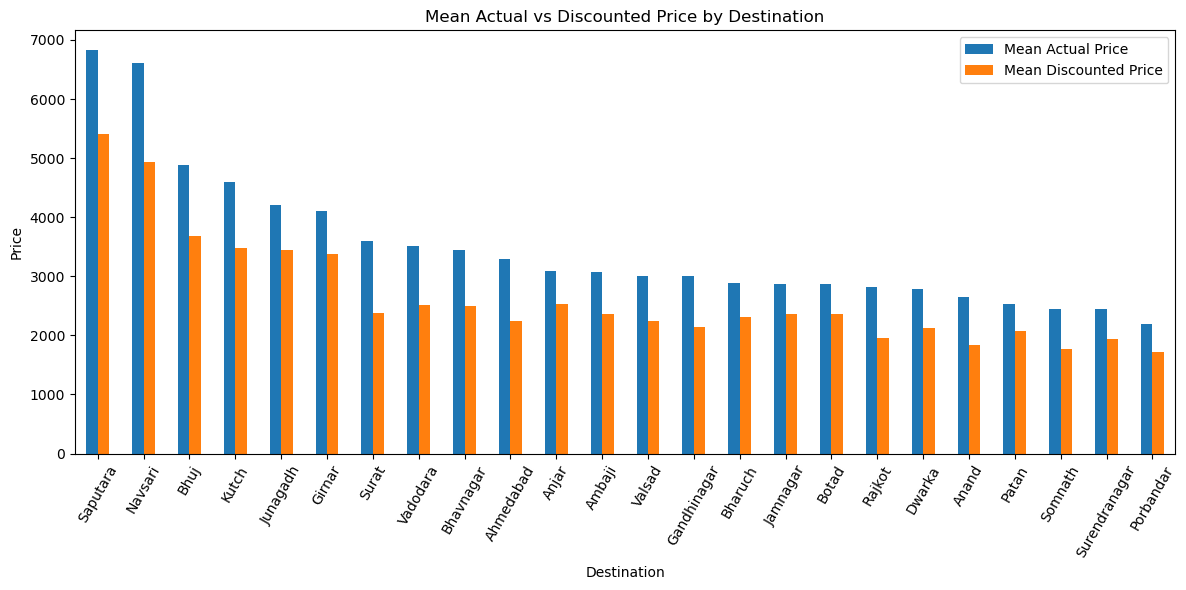

In [80]:
import matplotlib.pyplot as plt

price_summary.plot(kind='bar', figsize=(12,6))

plt.title("Mean Actual vs Discounted Price by Destination")
plt.ylabel("Price")
plt.xlabel("Destination")
plt.xticks(rotation=60)
plt.legend(["Mean Actual Price", "Mean Discounted Price"])

plt.tight_layout()
plt.show()

### Q5 : Find Hotel with Max Discount

In [89]:
hotel_info['discount'] =     (hotel_info['actual_price'] - hotel_info['discount_price'])


In [90]:
hotel_info[hotel_info.discount==hotel_info.discount.max()].hotel_name

555    Hotel Krishna Chandkheda
Name: hotel_name, dtype: object

### Q6. What is average of Actual Prices in Ambaaji

In [92]:
hotel_info[hotel_info.destination_name=='Ambaji'].actual_price.mean()

np.float64(3079.901639344262)

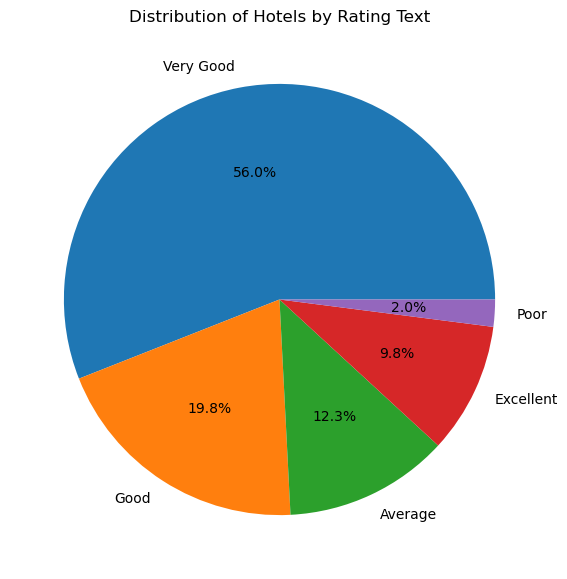

In [93]:
import matplotlib.pyplot as plt
rating_counts = hotel_info['rating_text'].value_counts()
rating_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Distribution of Hotels by Rating Text")
plt.ylabel("")   # removes default ylabel
plt.show()

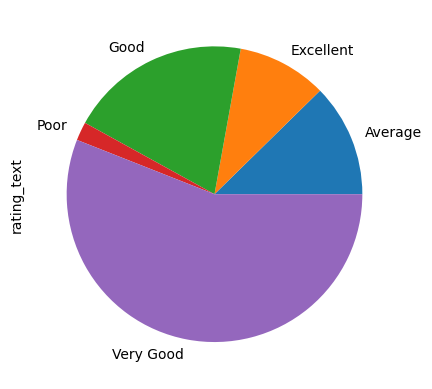

In [96]:
hotel_info.groupby('rating_text')['rating_text'].count().plot(kind='pie')
plt.show()

### Q 7 - Count of Ratings by bucket.

In [97]:
hotel_info['rating_bucket'] = pd.cut(
    hotel_info['rating'],
    bins=[1, 2, 3, 4, 5],
    labels=['1', '2', '3', '4'],
    include_lowest=True
)


C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_35320\2890203240.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hotel_info.groupby('rating_bucket')['rating_bucket'].count().plot(kind='pie')


<Axes: ylabel='rating_bucket'>

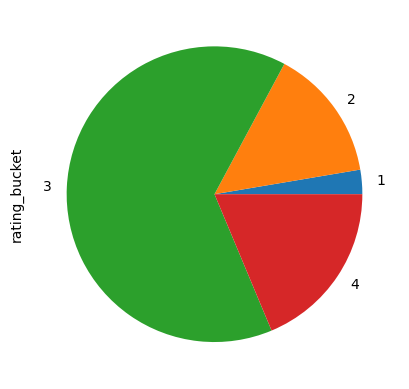

In [98]:
hotel_info.groupby('rating_bucket')['rating_bucket'].count().plot(kind='pie')